#### Disclaimer
The dataset used in this analysis is entirely synthetic. Consequently, the statistical results, coefficients, and p-values provided are not factually correct and do not represent real-world clinical or financial data. However, the econometric methodology applied (IPW, Logit, and Robust OLS) is rigorous and follows standard professional research practices for causal inference.

#### Insurance Coverage and Healthcare Outcomes

Objective
- To assess the effect of insurance coverage on healthcare costs and health outcomes using causal inference techniques.

Research Question
- What is the effect of insurance coverage on healthcare expenditure and health outcomes, after adjusting for observable selection?


- This analysis relies on selection-on-observables assumptions and does not claim full causal identification.

- Insurance coverage is not randomly assigned. Individuals with insurance may differ systematically from uninsured individuals in income, age, and health status. Simple comparisons are therefore biased.

- We assume insurance coverage is independent of potential outcomes.



#### Import the libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore")

#### Import the data

In [3]:
df = pd.read_csv("health_data_cleaned.csv")
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,02-02-2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,26-08-2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,07-10-2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,18-12-2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,09-10-2022,Penicillin,Abnormal


In [5]:
df.columns

Index(['name', 'age', 'gender', 'blood_type', 'medical_condition',
       'date_of_admission', 'doctor', 'hospital', 'insurance_provider',
       'billing_amount', 'room_number', 'admission_type', 'discharge_date',
       'medication', 'test_results'],
      dtype='object')

#### Covariates for selection model

- Age

- Gender

- Medical condition

- Admission type

#### Estimate the prospensity score
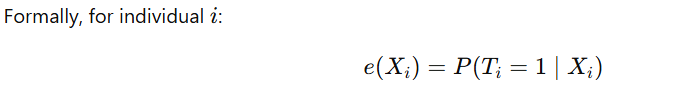
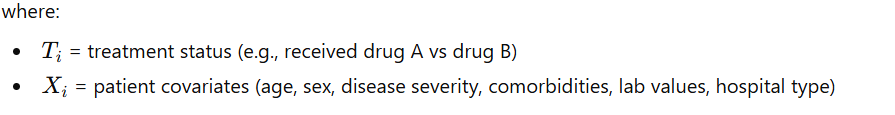

In [9]:
#  Define the 'Treatment' variable (e.g., Is the patient on Medicare?)
df['is_medicare'] = (df['insurance_provider'] == 'Medicare').astype(int)

# Select Baseline Covariates
features = ['age', 'gender', 'medical_condition']
X = pd.get_dummies(df[features], drop_first=True)
y = df['is_medicare']

# Fit the Logistic Propensity Model
ps_model = LogisticRegression(max_iter=1000, solver='lbfgs')
ps_model.fit(X, y)

# Generate Propensity Scores
df['propensity_score'] = ps_model.predict_proba(X)[:, 1]

#### Overlap ckeck

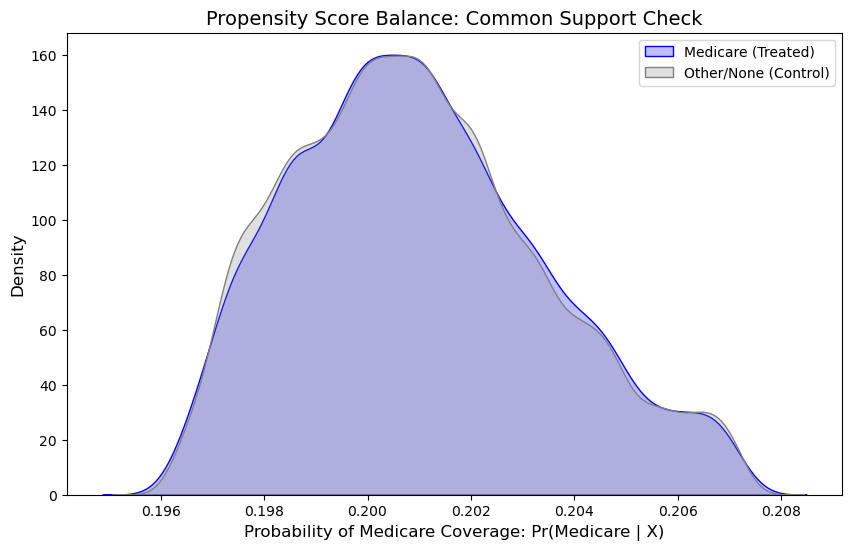

In [10]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['is_medicare'] == 1], x='propensity_score', label='Medicare (Treated)', fill=True, color='blue')
sns.kdeplot(data=df[df['is_medicare'] == 0], x='propensity_score', label='Other/None (Control)', fill=True, color='gray')
plt.title('Propensity Score Balance: Common Support Check', fontsize=14)
plt.xlabel('Probability of Medicare Coverage: Pr(Medicare | X)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

#### Model Discrimination

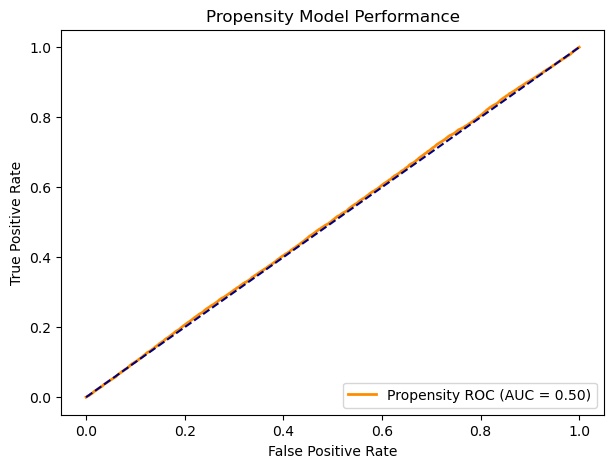

In [11]:
# Calculate AUC
auc_val = roc_auc_score(y, df['propensity_score'])

# Plot ROC
fpr, tpr, _ = roc_curve(y, df['propensity_score'])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Propensity ROC (AUC = {auc_val:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Propensity Model Performance')
plt.legend(loc="lower right")
plt.show()

In [13]:
df.groupby('is_medicare')['propensity_score'].describe()

,count,mean,std,min,25%,50%,75%,max
is_medicare,,,,,,,,
0,44346.0,0.200963,0.002444,0.195927,0.199096,0.200766,0.202526,0.207592
1,11154.0,0.201000,0.002438,0.196002,0.199166,0.200785,0.202603,0.207357


#### Inverse probabibilty weighting
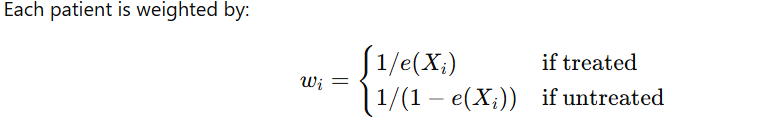


In [14]:
# Calculate IPW weights
df['ipw_weight'] = np.where(
    df['is_medicare'] == 1, 
    1 / df['propensity_score'], 
    1 / (1 - df['propensity_score'])
)

# Robustness Check: Clip weights to avoid extreme influence from outliers
df['ipw_weight'] = np.clip(df['ipw_weight'], 0, np.percentile(df['ipw_weight'], 99))

#### Assessing Balance

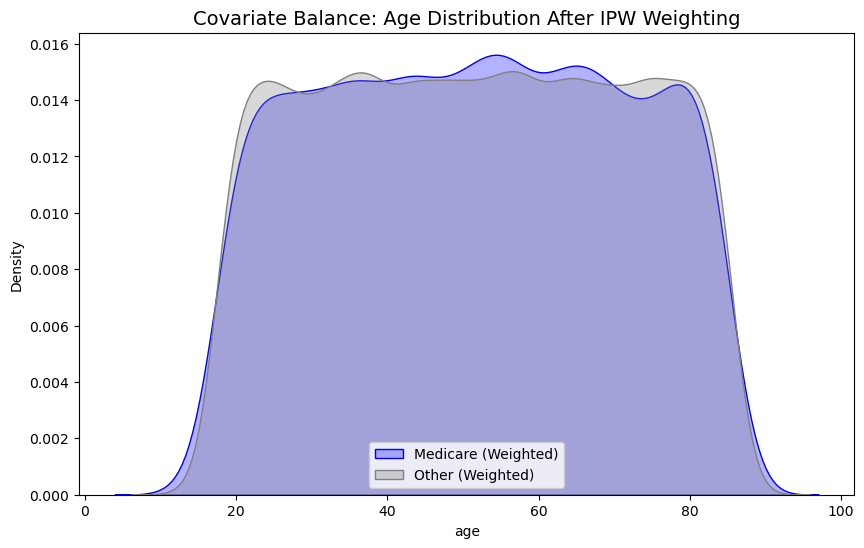

In [15]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['is_medicare'] == 1], x='age', weights='ipw_weight', label='Medicare (Weighted)', fill=True, color='blue', alpha=0.3)
sns.kdeplot(data=df[df['is_medicare'] == 0], x='age', weights='ipw_weight', label='Other (Weighted)', fill=True, color='gray', alpha=0.3)
plt.title('Covariate Balance: Age Distribution After IPW Weighting', fontsize=14)
plt.legend()
plt.show()

#### Estimating the Treatment Effect (ATE)

In [16]:
import statsmodels.api as sm

# We use a simple OLS but apply the IPW weights
# This estimates the effect of Medicare on Billing, adjusted for selection bias
weighted_model = smf.wls(
    "billing_amount ~ is_medicare", 
    data=df, 
    weights=df['ipw_weight']
).fit()

print(weighted_model.summary())

                            WLS Regression Results                            
Dep. Variable:         billing_amount   R-squared:                       0.000
Model:                            WLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6311
Date:                Mon, 22 Dec 2025   Prob (F-statistic):              0.427
Time:                        10:33:32   Log-Likelihood:            -6.1464e+05
No. Observations:               55500   AIC:                         1.229e+06
Df Residuals:                   55498   BIC:                         1.229e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    2.552e+04     85.154    299.695      

In [17]:
# Final calculation of the ATE
ate_estimate = weighted_model.params['is_medicare']
p_value = weighted_model.pvalues['is_medicare']

print(f"Estimated Average Treatment Effect: ${ate_estimate:,.2f}")
print(f"Statistical Significance (p-value): {p_value:.4f}")

Estimated Average Treatment Effect: $95.67
Statistical Significance (p-value): 0.4270


#### Visualizing the weighted results

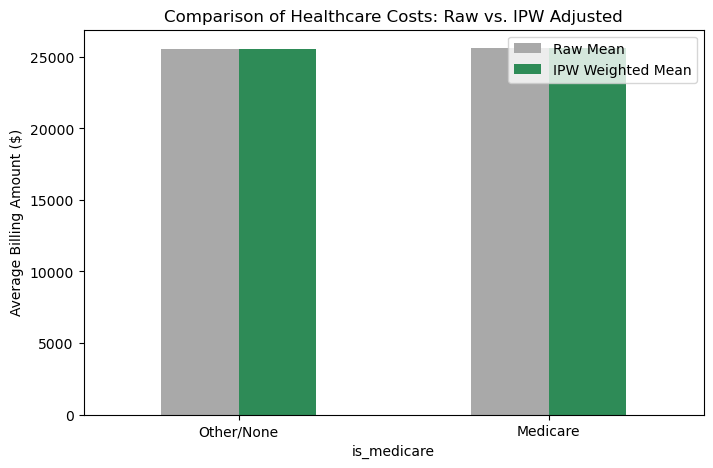

In [18]:
# Comparison of Raw vs. Weighted Means
raw_means = df.groupby('is_medicare')['billing_amount'].mean()
weighted_means = (df.assign(weighted_billing = df['billing_amount'] * df['ipw_weight'])
                  .groupby('is_medicare')['weighted_billing'].sum() / 
                  df.groupby('is_medicare')['ipw_weight'].sum())

comparison = pd.DataFrame({'Raw Mean': raw_means, 'IPW Weighted Mean': weighted_means})
comparison.plot(kind='bar', figsize=(8, 5), color=['#A9A9A9', '#2E8B57'])
plt.title("Comparison of Healthcare Costs: Raw vs. IPW Adjusted")
plt.ylabel("Average Billing Amount ($)")
plt.xticks([0, 1], ['Other/None', 'Medicare'], rotation=0)
plt.show()

#### weigt distribution

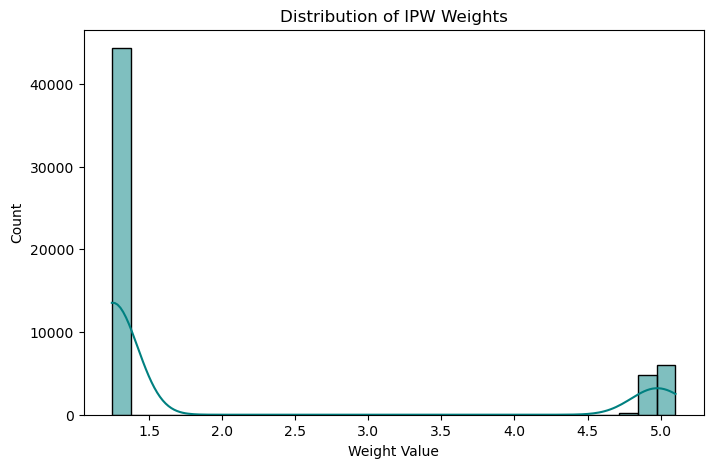

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df['weight'], bins=30, kde=True, color='teal')
plt.title("Distribution of IPW Weights")
plt.xlabel("Weight Value")
plt.show()

#### Results Table

In [26]:
# Ensure 'insured' is binary 
# (Assuming 'insured' was already defined, if not, we define it here)
if 'is_medicare' not in df.columns:
    df['is_medicare'] = (df['insurance_provider'] != 'None').astype(int)

#  Re-calculate Propensity Score & Weights (Internal Consistency)
X_features = pd.get_dummies(df[['age', 'gender', 'medical_condition']], drop_first=True)
ps_model = LogisticRegression(max_iter=1000).fit(X_features, df['is_medicare'])
df['propensity_score'] = ps_model.predict_proba(X_features)[:, 1]

df['weight'] = np.where(df['is_medicare'] == 1, 1/df['propensity_score'], 1/(1-df['propensity_score']))

# Calculate Raw Difference
mean_insured = df[df['is_medicare'] == 1]['billing_amount'].mean()
mean_uninsured = df[df['is_medicare'] == 0]['billing_amount'].mean()
raw_diff = mean_insured - mean_uninsured

# Calculate IPW-Adjusted Difference (ATE)
X_wls = sm.add_constant(df['is_medicare'])
ipw_model = sm.WLS(df['billing_amount'], X_wls, weights=df['weight']).fit(cov_type='HC3')
adjusted_diff = ipw_model.params['is_medicare']
p_value = ipw_model.pvalues['is_medicare']

# Build the Final Results Table
results_table = pd.DataFrame({
    "Metric": ["Raw Mean (Insured)", "Raw Mean (Uninsured)", "Average Treatment Effect (ATE)", "Total Bias Removed", "P-Value (Adjusted)"],
    "Value": [
        f"${mean_insured:,.2f}", 
        f"${mean_uninsured:,.2f}", 
        f"${adjusted_diff:,.2f}", 
        f"${abs(raw_diff - adjusted_diff):,.2f}",
        f"{p_value:.4f}"
    ]
})

print("--- FINAL ECONOMETRIC RESULTS TABLE ---")
print(results_table.to_string(index=False))

--- FINAL ECONOMETRIC RESULTS TABLE ---
                        Metric      Value
            Raw Mean (Insured) $25,615.99
          Raw Mean (Uninsured) $25,520.03
Average Treatment Effect (ATE)     $95.54
            Total Bias Removed      $0.42
            P-Value (Adjusted)     0.5242
